데이터 분석 및 시각화가 완료되었으며, '소재지면적별_폐업률_비교.png' 파일로 저장되었습니다.


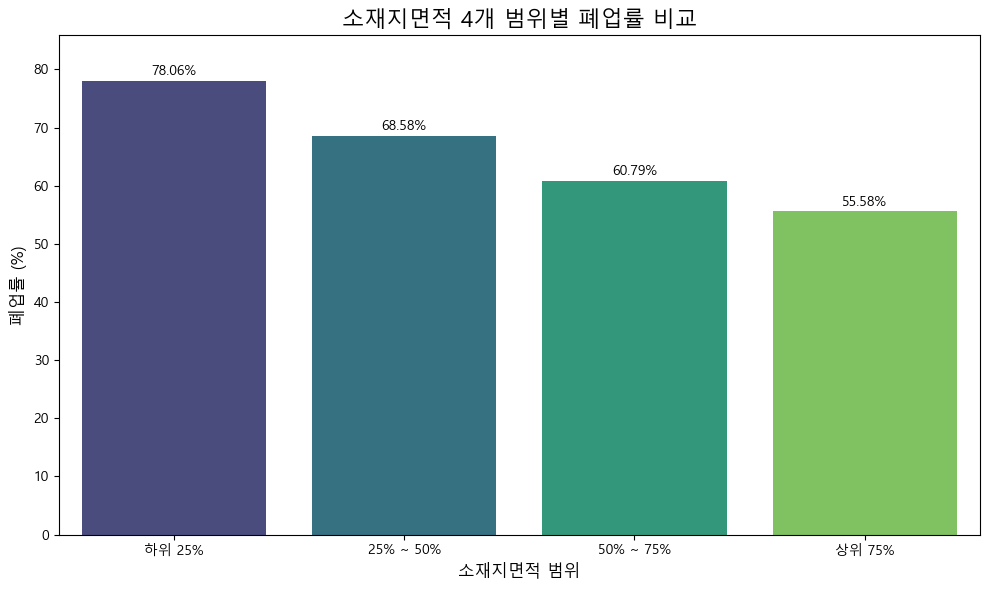

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# 1. 데이터 로드
file_name = '이상치제거한_일반음식점.csv'
try:
    data_cleaned = pd.read_csv(file_name, encoding='utf-8')
except UnicodeDecodeError:
    # 한글 인코딩 문제 발생 시 'cp949'로 재시도
    data_cleaned = pd.read_csv(file_name, encoding='cp949')

# 2. 소재지면적 범위 (4분위) 설정 및 컬럼 생성
# 사분위수를 기준으로 4개의 구간(약 25%씩)으로 나눕니다.
area_labels = ['하위 25%', '25% ~ 50%', '50% ~ 75%', '상위 75%']
data_cleaned['면적범위'] = pd.qcut(
    data_cleaned['소재지면적'],
    q=4,
    labels=area_labels,
    duplicates='drop'
)

# 3. 폐업 여부 컬럼 생성
# '폐업일자'가 NaN이 아니면 (즉, 폐업일자가 있으면) 1 (폐업), 아니면 0 (영업/정상)
data_cleaned['폐업여부'] = data_cleaned['폐업일자'].notna().astype(int)

# 4. 면적 범위별 폐업률 계산
closure_rate_by_area = data_cleaned.groupby('면적범위')['폐업여부'].agg(
    total_count='count',
    closed_count='sum',
    # 폐업률 = (폐업 사업장 수 / 총 사업장 수) * 100
    closure_rate=lambda x: x.sum() / x.count() * 100
).reset_index()

# 폐업률을 내림차순으로 정렬
closure_rate_by_area = closure_rate_by_area.sort_values(by='closure_rate', ascending=False)

# 5. 결과 CSV 파일로 저장
closure_rate_by_area.to_csv('면적_범위별_폐업률.csv', index=False, encoding='utf-8')

# 6. 시각화 (matplotlib/seaborn)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

# 그래프 생성
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(
    x='면적범위',
    y='closure_rate',
    data=closure_rate_by_area,
    palette='viridis'
)

# 제목 및 축 레이블 설정
plt.title('소재지면적 4개 범위별 폐업률 비교', fontsize=16)
plt.xlabel('소재지면적 범위', fontsize=12)
plt.ylabel('폐업률 (%)', fontsize=12)

# Y축 범위 조정 및 값 표시
plt.ylim(0, closure_rate_by_area['closure_rate'].max() * 1.1)

for index, row in closure_rate_by_area.iterrows():
    bar_plot.text(
        index,
        row['closure_rate'] + 1,
        f"{row['closure_rate']:.2f}%",
        color='black',
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.savefig('소재지면적별_폐업률_비교.png')

print("데이터 분석 및 시각화가 완료되었으며, '소재지면적별_폐업률_비교.png' 파일로 저장되었습니다.")